In [1]:
# Bootstrap — usa o pacote churn/ em vez de caminhos absolutos
import sys, pathlib
ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == 'notebooks' else pathlib.Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))

from churn.config import (
    RAW_CSV, CLEAN_CSV, PROCESSED_DIR, DOCS_DIR, MLFLOW_TRACKING_URI,
    EXPERIMENT_NAME, SEED, ensure_dirs,
)
ensure_dirs()
print('Raiz do projeto:', ROOT)


Raiz do projeto: /Users/matheusfiletti/Desktop/eng_de_machine_learning/Tech-Challenge-Fase1


# Notebook 02 — Modelos Baseline + MLflow Tracking

**Projeto:** Tech Challenge Fase 1
**Objetivo:** Treinar modelos baseline — DummyClassifier, Regressão Logística e LightGBM — e registrar todos os experimentos no MLflow.

---

## Índice
1. [Setup e Configuração do MLflow](#1-setup)
2. [Carregamento e Split dos Dados](#2-dados)
3. [Pipeline de Pré-processamento](#3-pipeline)
4. [Baseline 1 — Regressão Logística](#4-logistic)
5. [Baseline 2 — Regressão Logística](#4-logistic)
6. [Baseline 3 — LightGBM](#5-lgbm)
7. [Comparação dos Modelos](#6-comparacao)
8. [Auditoria de Fairness (Fairlearn)](#7-fairness)
9. [Registro Consolidado no MLflow](#8-registry)

## 1. Setup e Configuração do ML flow

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import logging
import optuna
import os

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score, precision_score,
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix, RocCurveDisplay,
)

import lightgbm as lgb
from lightgbm import LGBMClassifier

import mlflow
import mlflow.sklearn
import mlflow.lightgbm
from mlflow.models.signature import infer_signature

warnings.filterwarnings('ignore')
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s | %(levelname)-8s | %(message)s',
    datefmt='%H:%M:%S',
    force=True,
)
logger = logging.getLogger('churn_mlops')

SEED = 42
np.random.seed(SEED)

os.environ['MLFLOW_ALLOW_FILE_STORE'] = 'true'

URI_PATH = MLFLOW_TRACKING_URI
mlflow.set_tracking_uri(URI_PATH)

EXPERIMENT_NAME = 'churn-prediction-fase1'
mlflow.set_experiment(EXPERIMENT_NAME)

#EXPERIMENT_NAME = 'churn-prediction-fase1'
#mlflow.set_experiment(EXPERIMENT_NAME)

logger.info('Setup completo | LightGBM %s | MLflow %s | Experimento: %s',
            lgb.__version__, mlflow.get_tracking_uri(), EXPERIMENT_NAME)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026/08/22 10:03:24 INFO mlflow.tracking.fluent: Experiment with name 'churn-prediction-fase1' does not exist. Creating a new experiment.
10:03:24 | INFO     | Setup completo | LightGBM 4.5.0 | MLflow file:///Users/matheusfiletti/Desktop/eng_de_machine_learning/Tech-Challenge-Fase1/mlruns | Experimento: churn-prediction-fase1


In [3]:
# Carregamento 
data_path = str(CLEAN_CSV)
df = pd.read_csv(data_path)

print(f'Dataset carregado: {df.shape}')

Dataset carregado: (7043, 21)


In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [5]:
target = 'Churn'
drop_cols = ['customerID','TotalCharges']

X = df.drop(columns=[target] + drop_cols)
y = df[target]



num_features = ['tenure', 'MonthlyCharges', 'SeniorCitizen']
cat_features = [c for c in X.columns if c not in num_features]

print(f'Features numéricas: {num_features}')
print(f'Features categóricas: {cat_features}')
print(f'Distribuição do target:')
print(y.value_counts(normalize=True).mul(100).round(1).to_string())

Features numéricas: ['tenure', 'MonthlyCharges', 'SeniorCitizen']
Features categóricas: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Distribuição do target:
Churn
0    73.5
1    26.5


## 2. Carregamento e Split dos Dados

In [6]:
# Split estratificado: 70% treino | 15% val | 15% teste
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=SEED, stratify=y_temp
)

print('Split estratificado:')
print(f'   Treino    : {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%) | churn: {y_train.mean()*100:.1f}%')
print(f'   Validação : {len(X_val):,} ({len(X_val)/len(X)*100:.1f}%)  | churn: {y_val.mean()*100:.1f}%')
print(f'   Teste     : {len(X_test):,} ({len(X_test)/len(X)*100:.1f}%)  | churn: {y_test.mean()*100:.1f}%')

Split estratificado:
   Treino    : 4,929 (70.0%) | churn: 26.5%
   Validação : 1,057 (15.0%)  | churn: 26.6%
   Teste     : 1,057 (15.0%)  | churn: 26.5%


## 3. Pipeline de Pré-processamento

In [7]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer,     num_features),
    ('cat', categorical_transformer, cat_features),
])

print('Preprocessor definido:')
print('   Numéricas   → SimpleImputer(median) → StandardScaler')
print('   Categóricas → SimpleImputer(mode)   → OneHotEncoder')

Preprocessor definido:
   Numéricas   → SimpleImputer(median) → StandardScaler
   Categóricas → SimpleImputer(mode)   → OneHotEncoder


In [8]:
def calcular_metricas(y_true, y_pred, y_proba=None, nome='Modelo'):
    """Calcula e retorna as métricas principais."""
    metricas = {
        'accuracy' : accuracy_score(y_true, y_pred),
        'f1'       : f1_score(y_true, y_pred, zero_division=0),
        'recall'   : recall_score(y_true, y_pred, zero_division=0),
        'precision': precision_score(y_true, y_pred, zero_division=0),
    }
    if y_proba is not None:
        metricas['auc_roc'] = roc_auc_score(y_true, y_proba)
        metricas['pr_auc']  = average_precision_score(y_true, y_proba)

    print(f'\n📊 {nome} — Métricas no Conjunto de Teste')
    print('-' * 45)
    for k, v in metricas.items():
        flag = 'Alerta' if k == 'recall' and v < 0.75 else 'Ok'
        print(f'  {flag} {k:12s}: {v:.4f}')
    return metricas

## 4.Baseline 1 - DummyClassifier

In [9]:
DUMMY_PARAMS = {
    'strategy'    : 'most_frequent',
    'random_state': SEED,
}

dummy_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   DummyClassifier(**DUMMY_PARAMS)),
])

dummy_pipeline.fit(X_train, y_train)
y_pred_dummy  = dummy_pipeline.predict(X_test)

try:
    y_proba_dummy = dummy_pipeline.predict_proba(X_test)[:, 1]
except Exception:
    y_proba_dummy = None

metricas_dummy = calcular_metricas(y_test, y_pred_dummy, y_proba_dummy, 'DummyClassifier')

with mlflow.start_run(run_name='baseline-dummy-classifier') as run:
    for k, v in DUMMY_PARAMS.items():
        mlflow.log_param(k, v)
    mlflow.log_param('model_type', 'DummyClassifier')
    mlflow.log_param('train_size', len(X_train))

    for k, v in metricas_dummy.items():
        mlflow.log_metric(k, v)

    signature = infer_signature(X_train, dummy_pipeline.predict(X_train))
    mlflow.sklearn.log_model(
        dummy_pipeline,
        artifact_path='model',
        signature=signature,
        registered_model_name='churn-dummy-baseline',
        serialization_format=mlflow.sklearn.SERIALIZATION_FORMAT_CLOUDPICKLE,
    )
    mlflow.set_tag('stage', 'baseline')
    mlflow.set_tag('dataset_version', 'v1.0')
    dummy_run_id = run.info.run_id

logger.info('DummyClassifier registrado no MLflow | Run ID: %s', dummy_run_id[:8])
logger.info('Este e o piso minimo — qualquer modelo util deve superar estas metricas')




📊 DummyClassifier — Métricas no Conjunto de Teste
---------------------------------------------
  Ok accuracy    : 0.7351
  Ok f1          : 0.0000
  Alerta recall      : 0.0000
  Ok precision   : 0.0000
  Ok auc_roc     : 0.5000
  Ok pr_auc      : 0.2649


2026/08/22 10:03:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/22 10:03:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'churn-dummy-baseline'.
Created version '1' of model 'churn-dummy-baseline'.
10:03:45 | INFO     | DummyClassifier registrado no MLflow | Run ID: 3066c427
10:03:45 | INFO     | Este e o piso minimo — qualquer modelo util deve superar estas metricas


## 5. Baseline 2 — Regressão Logística

In [10]:
LR_PARAMS = {
    'C'            : 1.0,
    'max_iter'     : 1000,
    #'solver'       : 'lbfgs',
    'solver': 'liblinear',
    'class_weight' : 'balanced',
    'random_state' : SEED,
    'penalty': 'l1'
}

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   LogisticRegression(**LR_PARAMS)),
])

# Validação cruzada estratificada (5-fold)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_lr = cross_validate(
    lr_pipeline, X_train, y_train, cv=cv,
    scoring=['accuracy', 'f1', 'recall', 'precision', 'roc_auc'],
)

print('Validação Cruzada (5-fold) — Regressão Logística')
print('-' * 50)
for m in ['accuracy', 'f1', 'recall', 'precision', 'roc_auc']:
    s = cv_lr[f'test_{m}']
    print(f'  {m:12s}: {s.mean():.4f} ± {s.std():.4f}')

Validação Cruzada (5-fold) — Regressão Logística
--------------------------------------------------
  accuracy    : 0.7519 ± 0.0035
  f1          : 0.6325 ± 0.0082
  recall      : 0.8050 ± 0.0244
  precision   : 0.5211 ± 0.0043
  roc_auc     : 0.8453 ± 0.0043


In [11]:
lr_pipeline.fit(X_train, y_train)
y_pred_lr  = lr_pipeline.predict(X_test)
y_proba_lr = lr_pipeline.predict_proba(X_test)[:, 1]

metricas_lr = calcular_metricas(y_test, y_pred_lr, y_proba_lr, 'Regressão Logística')
print()
print(classification_report(y_test, y_pred_lr, target_names=['Não Churn', 'Churn']))


📊 Regressão Logística — Métricas no Conjunto de Teste
---------------------------------------------
  Ok accuracy    : 0.7379
  Ok f1          : 0.6169
  Ok recall      : 0.7964
  Ok precision   : 0.5034
  Ok auc_roc     : 0.8467
  Ok pr_auc      : 0.6372

              precision    recall  f1-score   support

   Não Churn       0.91      0.72      0.80       777
       Churn       0.50      0.80      0.62       280

    accuracy                           0.74      1057
   macro avg       0.71      0.76      0.71      1057
weighted avg       0.80      0.74      0.75      1057



In [12]:
with mlflow.start_run(run_name='baseline-logistic-regression') as run:
    for k, v in LR_PARAMS.items():
        mlflow.log_param(k, v)
    mlflow.log_param('model_type', 'LogisticRegression')
    mlflow.log_param('train_size', len(X_train))
    mlflow.log_param('cv_folds',   5)

    for k, v in metricas_lr.items():
        mlflow.log_metric(k, v)
    for m in ['accuracy', 'f1', 'recall', 'precision', 'roc_auc']:
        s = cv_lr[f'test_{m}']
        mlflow.log_metric(f'cv_{m}_mean', s.mean())
        mlflow.log_metric(f'cv_{m}_std',  s.std())

    signature = infer_signature(X_train, lr_pipeline.predict(X_train))
    mlflow.sklearn.log_model(
        lr_pipeline, 
        artifact_path='model', 
        signature=signature,
        registered_model_name='churn-logistic-baseline',
        serialization_format=mlflow.sklearn.SERIALIZATION_FORMAT_CLOUDPICKLE # Volta para o método antigo
    )
    mlflow.set_tag('stage', 'baseline')
    mlflow.set_tag('dataset_version', 'v1.0')
    lr_run_id = run.info.run_id

print(f'Regressão Logística registrada no MLflow — Run ID: {lr_run_id[:8]}')

2026/08/22 10:03:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/22 10:03:49 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Regressão Logística registrada no MLflow — Run ID: 2e690de6


Successfully registered model 'churn-logistic-baseline'.
Created version '1' of model 'churn-logistic-baseline'.


## 5. Baseline 3 — LightGBM

In [13]:
def objective(trial):
    lgm_params = {
        'n_estimators'  : trial.suggest_int('n_estimators', 50, 500),
        'learning_rate' : trial.suggest_float('learning_rate', 0.01, 0.05, log=True),
        'max_depth'     : trial.suggest_int('max_depth', 3, 10),
        'num_leaves'    : trial.suggest_int('num_leaves', 20, 100),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'class_weight'  : 'balanced',
        'random_state'  : SEED,
        'n_jobs'        : -1,
        'verbose'       : -1,
    }
    # Optuna 
    k_features = trial.suggest_int('k', 10, 35)

    # Pipeline temporário criado apenas para esta tentativa do Optuna
    pipeline_teste = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('feature_selection', SelectKBest(f_classif, k=k_features)),
        ('classifier',   LGBMClassifier(**lgm_params)),
    ])

    # Validação cruzada focada em uma métrica (ROC AUC) para guiar o Optuna
    cv_resultados = cross_validate(
        pipeline_teste, X_train, y_train, cv=cv,
        scoring='roc_auc', 
        n_jobs=-1
    )

    # Retorna a média da métrica para o Optuna avaliar
    return cv_resultados['test_score'].mean()

print("Iniciando otimização com Optuna...")
# Cria o estudo pedindo para maximizar a nota
study = optuna.create_study(direction='maximize')
# Roda 30 tentativas (aumente se quiser)
study.optimize(objective, n_trials=30)

print(f"\nBusca concluída! Melhor ROC AUC: {study.best_value:.4f}")

[I 2026-08-22 10:03:51,508] A new study created in memory with name: no-name-58c3e699-2669-48f9-a5bb-afc97d72aecc


Iniciando otimização com Optuna...


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/pytho


Busca concluída! Melhor ROC AUC: 0.8463


In [14]:
from sklearn.metrics import classification_report

# 1. Faz uma cópia dos melhores parâmetros para não mexer no original do Optuna
melhores_parametros = study.best_params.copy()
melhor_k = melhores_parametros.pop('k')

# 2. Adiciona os parâmetros fixos que não entraram na busca
melhores_parametros['class_weight'] = 'balanced'
melhores_parametros['random_state'] = SEED
melhores_parametros['n_jobs'] = -1
melhores_parametros['verbose'] = -1

# 3. Cria o Pipeline DEFINITIVO com a melhor configuração
lgbm_pipeline_final = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('selector',     SelectKBest(score_func=f_classif, k=melhor_k)),
    ('classifier',   LGBMClassifier(**melhores_parametros)),
])

# 4. Treina o modelo final com os dados de treino completos
lgbm_pipeline_final.fit(X_train, y_train)

# 5. Faz as previsões nos dados de Teste
y_pred_lgbm  = lgbm_pipeline_final.predict(X_test)
y_proba_lgbm = lgbm_pipeline_final.predict_proba(X_test)[:, 1]

# 6. Exibe os resultados finais
metricas_lgbm = calcular_metricas(y_test, y_pred_lgbm, y_proba_lgbm, 'LightGBM Otimizado')
print("\nRelatório de Classificação - LightGBM Otimizado:")
print('-' * 50)
print(classification_report(y_test, y_pred_lgbm, target_names=['Não Churn', 'Churn']))


📊 LightGBM Otimizado — Métricas no Conjunto de Teste
---------------------------------------------
  Ok accuracy    : 0.7616
  Ok f1          : 0.6461
  Ok recall      : 0.8214
  Ok precision   : 0.5324
  Ok auc_roc     : 0.8506
  Ok pr_auc      : 0.6555

Relatório de Classificação - LightGBM Otimizado:
--------------------------------------------------
              precision    recall  f1-score   support

   Não Churn       0.92      0.74      0.82       777
       Churn       0.53      0.82      0.65       280

    accuracy                           0.76      1057
   macro avg       0.73      0.78      0.73      1057
weighted avg       0.82      0.76      0.77      1057



In [15]:
with mlflow.start_run(run_name='optimized-lightgbm') as run:
    # Registra a quantidade de features escolhidas pelo SelectKBest
    mlflow.log_param('k_features', melhor_k)
    # Registra os melhores parâmetros encontrados pelo Optuna + os fixos
    for k, v in melhores_parametros.items():
        mlflow.log_param(k, v)
        
    mlflow.log_param('model_type', 'LightGBM Otimizado')
    mlflow.log_param('train_size', len(X_train))

    # Registra as métricas finais de teste
    for k, v in metricas_lgbm.items():
        mlflow.log_metric(k, v)

    # Salva o modelo 
    signature = infer_signature(X_train, lgbm_pipeline_final.predict(X_train))
    
    mlflow.sklearn.log_model(
        lgbm_pipeline_final, 
        artifact_path='model', 
        signature=signature,
        registered_model_name='churn-lgbm-optimized', 
        serialization_format=mlflow.sklearn.SERIALIZATION_FORMAT_CLOUDPICKLE
    )
    
    # Atualiza as tags para manter a organização
    mlflow.set_tag('stage', 'optimized')
    mlflow.set_tag('dataset_version', 'v1.0')
    mlflow.set_tag('optuna_optimization', 'true')
    
    lgbm_run_id = run.info.run_id

print(f'\nLightGBM Otimizado registrado no MLflow — Run ID: {lgbm_run_id[:8]}')

2026/08/22 10:04:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/22 10:04:54 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



LightGBM Otimizado registrado no MLflow — Run ID: 82e75ff1


Successfully registered model 'churn-lgbm-optimized'.
Created version '1' of model 'churn-lgbm-optimized'.


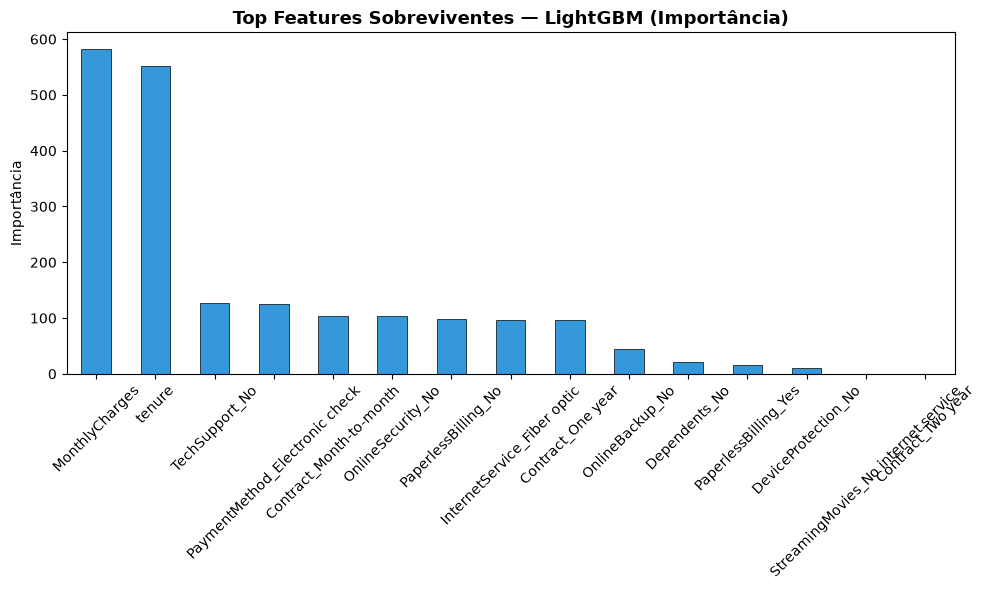


Top 5 features mais importantes (Dentre as selecionadas):
  MonthlyCharges                          : 583
  tenure                                  : 552
  TechSupport_No                          : 127
  PaymentMethod_Electronic check          : 126
  Contract_Month-to-month                 : 104


In [16]:
# Isolar os passos do pipeline
preprocessor = lgbm_pipeline_final.named_steps['preprocessor']
seletor      = lgbm_pipeline_final.named_steps['selector']
lgbm_clf     = lgbm_pipeline_final.named_steps['classifier']

# Recuperar os nomes das features geradas pelo preprocessor
ohe_cols = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(cat_features).tolist()
todas_as_features = np.array(num_features + ohe_cols)

# Filtrar features do selectkBest
mascara_sobreviventes = seletor.get_support()
features_finais = todas_as_features[mascara_sobreviventes]

importances = pd.Series(lgbm_clf.feature_importances_, index=features_finais).sort_values(ascending=False)

# 5. Plotar o gráfico (Exatamente o seu código, que estava ótimo!)
fig, ax = plt.subplots(figsize=(10, 6))
importances.head(15).plot(kind='bar', ax=ax, color='#3498db', edgecolor='black', linewidth=0.5)
ax.set_title('Top Features Sobreviventes — LightGBM (Importância)', fontsize=13, fontweight='bold')
ax.set_ylabel('Importância')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print('\nTop 5 features mais importantes (Dentre as selecionadas):')
for feat, imp in importances.head(5).items():
    print(f'  {feat:40s}: {imp:.0f}')

## 6. Comparação dos Modelos

In [17]:
# Tabela comparativa com os 3 baselines
comp = pd.DataFrame({
    'DummyClassifier'    : metricas_dummy,
    'Regressão Logística': metricas_lr,
    'LightGBM (Optuna)' : metricas_lgbm,
}).T.round(4)

logger.info('TABELA COMPARATIVA — 3 BASELINES')
display(comp)

melhor = max(
    [('DummyClassifier', metricas_dummy),
     ('Logistic Regression', metricas_lr),
     ('LightGBM', metricas_lgbm)],
    key=lambda x: x[1].get('auc_roc', 0)
)[0]
logger.info('Melhor baseline (AUC-ROC): %s', melhor)
logger.info('Threshold que a MLP deve superar:')
logger.info('  AUC-ROC >= %.4f', max(metricas_dummy.get('auc_roc',0),
    metricas_lr.get('auc_roc',0), metricas_lgbm.get('auc_roc',0)))
logger.info('  Recall  >= %.4f', max(metricas_dummy.get('recall',0),
    metricas_lr.get('recall',0), metricas_lgbm.get('recall',0)))

10:04:57 | INFO     | TABELA COMPARATIVA — 3 BASELINES


,accuracy,f1,recall,precision,auc_roc,pr_auc
DummyClassifier,0.7351,0.0000,0.0000,0.0000,0.5000,0.2649
Regressão Logística,0.7379,0.6169,0.7964,0.5034,0.8467,0.6372
LightGBM (Optuna),0.7616,0.6461,0.8214,0.5324,0.8506,0.6555


10:04:57 | INFO     | Melhor baseline (AUC-ROC): LightGBM
10:04:57 | INFO     | Threshold que a MLP deve superar:
10:04:57 | INFO     |   AUC-ROC >= 0.8506
10:04:57 | INFO     |   Recall  >= 0.8214


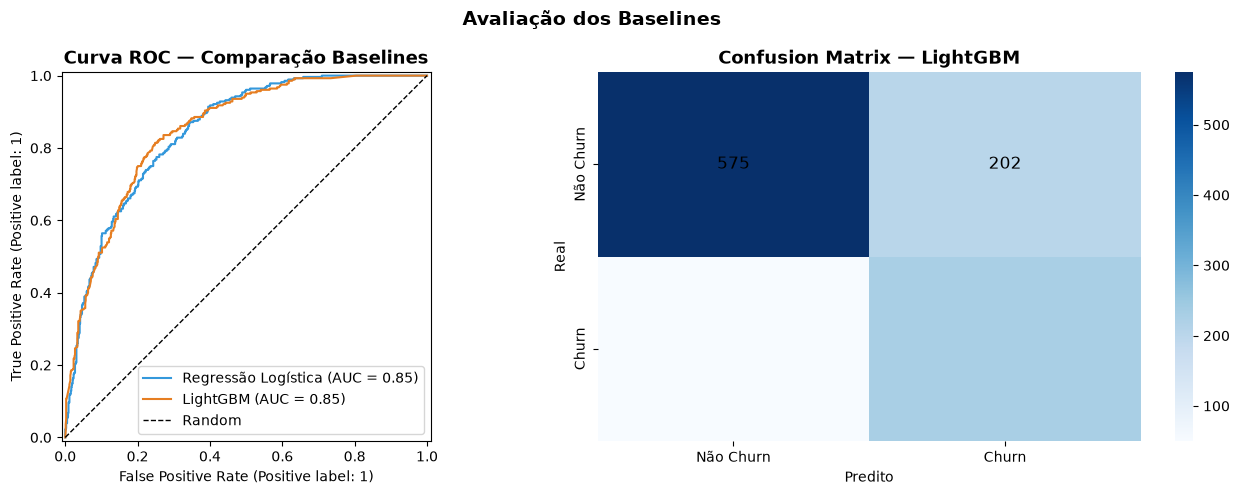

In [18]:
# Curvas ROC + Confusion Matrix do LightGBM
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

RocCurveDisplay.from_predictions(y_test, y_proba_lr,   name='Regressão Logística', ax=axes[0], color='#3498db')
RocCurveDisplay.from_predictions(y_test, y_proba_lgbm, name='LightGBM',            ax=axes[0], color='#e67e22')
axes[0].plot([0,1],[0,1],'k--', lw=1, label='Random')
axes[0].set_title('Curva ROC — Comparação Baselines', fontsize=13, fontweight='bold')
axes[0].legend()

cm = confusion_matrix(y_test, y_pred_lgbm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Não Churn', 'Churn'],
            yticklabels=['Não Churn', 'Churn'],
            annot_kws={"color": "black", "size": 12})

axes[1].set_title('Confusion Matrix — LightGBM', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Real')
axes[1].set_xlabel('Predito')

plt.suptitle('Avaliação dos Baselines', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(str(DOCS_DIR / 'baselines_roc_confusion.png'), dpi=150, bbox_inches='tight')
plt.show()

In [19]:
logger.info("Confusion Matrix (LightGBM):\n%s", cm)

10:05:17 | INFO     | Confusion Matrix (LightGBM):
[[575 202]
 [ 50 230]]


In [20]:
# ── Output do modelo: qual cliente é churn ou não ──────────────

# 1. Montar DataFrame com customerID + real + predito
predictions_df = df.loc[X_test.index, ['customerID']].copy()
predictions_df['y_true']        = y_test.values
predictions_df['y_pred_lgbm']   = y_pred_lgbm
predictions_df['y_proba_lgbm']  = y_proba_lgbm.round(4)
predictions_df['y_pred_lr']     = y_pred_lr
predictions_df['y_proba_lr']    = y_proba_lr.round(4)

# 2. Classificar em faixas de risco (para o CRM)
def faixa_risco(proba):
    if proba >= 0.70:
        return 'alto'
    elif proba >= 0.40:
        return 'medio'
    else:
        return 'baixo'

predictions_df['risco'] = predictions_df['y_proba_lgbm'].apply(faixa_risco)

# 3. Salvar em processed/
output_path = str(PROCESSED_DIR / 'predictions_baselines.csv')
predictions_df.to_csv(output_path, index=False)

print(f'{len(predictions_df)} predições salvas em {output_path}')
print(f'\nDistribuição das predições (LightGBM):')
print(predictions_df['y_pred_lgbm'].value_counts().rename({0: 'Não Churn', 1: 'Churn'}))
print(f'\nDistribuição por faixa de risco:')
print(predictions_df['risco'].value_counts())

1057 predições salvas em /Users/matheusfiletti/Desktop/eng_de_machine_learning/Tech-Challenge-Fase1/data/processed/predictions_baselines.csv

Distribuição das predições (LightGBM):
y_pred_lgbm
Não Churn    625
Churn        432
Name: count, dtype: int64

Distribuição por faixa de risco:
risco
baixo    511
medio    370
alto     176
Name: count, dtype: int64


In [21]:
client = mlflow.tracking.MlflowClient()
experiment = client.get_experiment_by_name(EXPERIMENT_NAME)

runs = client.search_runs(
    experiment_ids=[experiment.experiment_id],
    order_by=['metrics.auc_roc DESC'],
)

logger.info('Experimento: {EXPERIMENT_NAME}')
logger.info('Total de runs: {len(runs)}')
logger.info('\nRuns (ordenadas por AUC-ROC):')
logger.info('-' * 75)
for r in runs:
    name   = r.data.tags.get('mlflow.runName', 'N/A')
    auc    = r.data.metrics.get('auc_roc', 0)
    recall = r.data.metrics.get('recall',  0)
    f1     = r.data.metrics.get('f1',      0)
    logger.info('  [{r.info.run_id[:8]}] {name:40s} | AUC: {auc:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}')

10:05:19 | INFO     | Experimento: {EXPERIMENT_NAME}
10:05:19 | INFO     | Total de runs: {len(runs)}
10:05:19 | INFO     | 
Runs (ordenadas por AUC-ROC):
10:05:19 | INFO     | ---------------------------------------------------------------------------
10:05:19 | INFO     |   [{r.info.run_id[:8]}] {name:40s} | AUC: {auc:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}
10:05:19 | INFO     |   [{r.info.run_id[:8]}] {name:40s} | AUC: {auc:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}
10:05:19 | INFO     |   [{r.info.run_id[:8]}] {name:40s} | AUC: {auc:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}


In [22]:
logger.info('Para ver os experimentos:')
logger.info('$ mlflow ui --backend-store-uri file:./models')

10:05:20 | INFO     | Para ver os experimentos:
10:05:20 | INFO     | $ mlflow ui --backend-store-uri file:./models
